In [1]:
# entire data set is considered as root node 
# target values is preferred to be categorial
# in order to choose attributes as root or internal nodes is should done some statistical approach
#dt makes binary split each node is splitted 2 base single feature
#dt uses recursive partitioning process in which a node is divided into sub nodes until stop criteria is met

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Abeyaantrix2Internship/intern/main/Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
df1 = df.drop('User ID',axis =1,inplace=True)
df1

In [5]:
x = df.iloc[:,:-1]
print(x)

     Gender  Age  EstimatedSalary
0      Male   19            19000
1      Male   35            20000
2    Female   26            43000
3    Female   27            57000
4      Male   19            76000
..      ...  ...              ...
395  Female   46            41000
396    Male   51            23000
397  Female   50            20000
398    Male   36            33000
399  Female   49            36000

[400 rows x 3 columns]


In [6]:
x = df.iloc[:,:-1]
print(x)
print(x.shape)

     Gender  Age  EstimatedSalary
0      Male   19            19000
1      Male   35            20000
2    Female   26            43000
3    Female   27            57000
4      Male   19            76000
..      ...  ...              ...
395  Female   46            41000
396    Male   51            23000
397  Female   50            20000
398    Male   36            33000
399  Female   49            36000

[400 rows x 3 columns]
(400, 3)


In [8]:
y = df.iloc[:,-1:]
print(y)
print(y.shape)

     Purchased
0            0
1            0
2            0
3            0
4            0
..         ...
395          1
396          1
397          1
398          0
399          1

[400 rows x 1 columns]
(400, 1)


In [9]:
pd.get_dummies(df['Gender'],drop_first=True)

,Male
0,True
1,True
2,False
3,False
4,True
...,...
395,False
396,True
397,False
398,True


In [11]:
from sklearn.preprocessing import OneHotEncoder
g = OneHotEncoder()
a=g.fit_transform(df[['Gender']])
gender = pd.DataFrame(a.toarray())
gender

,0,1
0,0.0,1.0
1,0.0,1.0
2,1.0,0.0
3,1.0,0.0
4,0.0,1.0
...,...,...
395,1.0,0.0
396,0.0,1.0
397,1.0,0.0
398,0.0,1.0


In [12]:
df = pd.concat([df,gender],axis=1)
df

,Gender,Age,EstimatedSalary,Purchased,0,1
0,Male,19,19000,0,0.0,1.0
1,Male,35,20000,0,0.0,1.0
2,Female,26,43000,0,1.0,0.0
3,Female,27,57000,0,1.0,0.0
4,Male,19,76000,0,0.0,1.0
...,...,...,...,...,...,...
395,Female,46,41000,1,1.0,0.0
396,Male,51,23000,1,0.0,1.0
397,Female,50,20000,1,1.0,0.0
398,Male,36,33000,0,0.0,1.0


In [14]:
df.drop(columns=['Gender',1],axis=1,inplace=True)
df

,Age,EstimatedSalary,Purchased,0
0,19,19000,0,0.0
1,35,20000,0,0.0
2,26,43000,0,1.0
3,27,57000,0,1.0
4,19,76000,0,0.0
...,...,...,...,...
395,46,41000,1,1.0
396,51,23000,1,0.0
397,50,20000,1,1.0
398,36,33000,0,0.0


In [15]:
x = df[["Age","EstimatedSalary",0]]
print(x)
print(x.shape)

     Age  EstimatedSalary    0
0     19            19000  0.0
1     35            20000  0.0
2     26            43000  1.0
3     27            57000  1.0
4     19            76000  0.0
..   ...              ...  ...
395   46            41000  1.0
396   51            23000  0.0
397   50            20000  1.0
398   36            33000  0.0
399   49            36000  1.0

[400 rows x 3 columns]
(400, 3)


In [16]:
print(x.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              400 non-null    int64  
 1   EstimatedSalary  400 non-null    int64  
 2   0                400 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 9.5 KB
None


In [17]:
x['0']=x[0].astype("int64")

In [18]:
x.drop(0,axis=1,inplace=True)

In [19]:
x

,Age,EstimatedSalary,0
0,19,19000,0
1,35,20000,0
2,26,43000,1
3,27,57000,1
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,0
397,50,20000,1
398,36,33000,0


In [20]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x = sc.fit_transform(x)
x

array([[-1.78179743, -1.49004624, -1.02020406],
       [-0.25358736, -1.46068138, -1.02020406],
       [-1.11320552, -0.78528968,  0.98019606],
       ...,
       [ 1.17910958, -1.46068138,  0.98019606],
       [-0.15807423, -1.07893824, -1.02020406],
       [ 1.08359645, -0.99084367,  0.98019606]], shape=(400, 3))

In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
print(x_train.shape,x_test.shape)

(300, 3) (100, 3)


In [22]:
from sklearn.tree import DecisionTreeClassifier
mod  = DecisionTreeClassifier(criterion='gini',max_depth=4)
mod.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


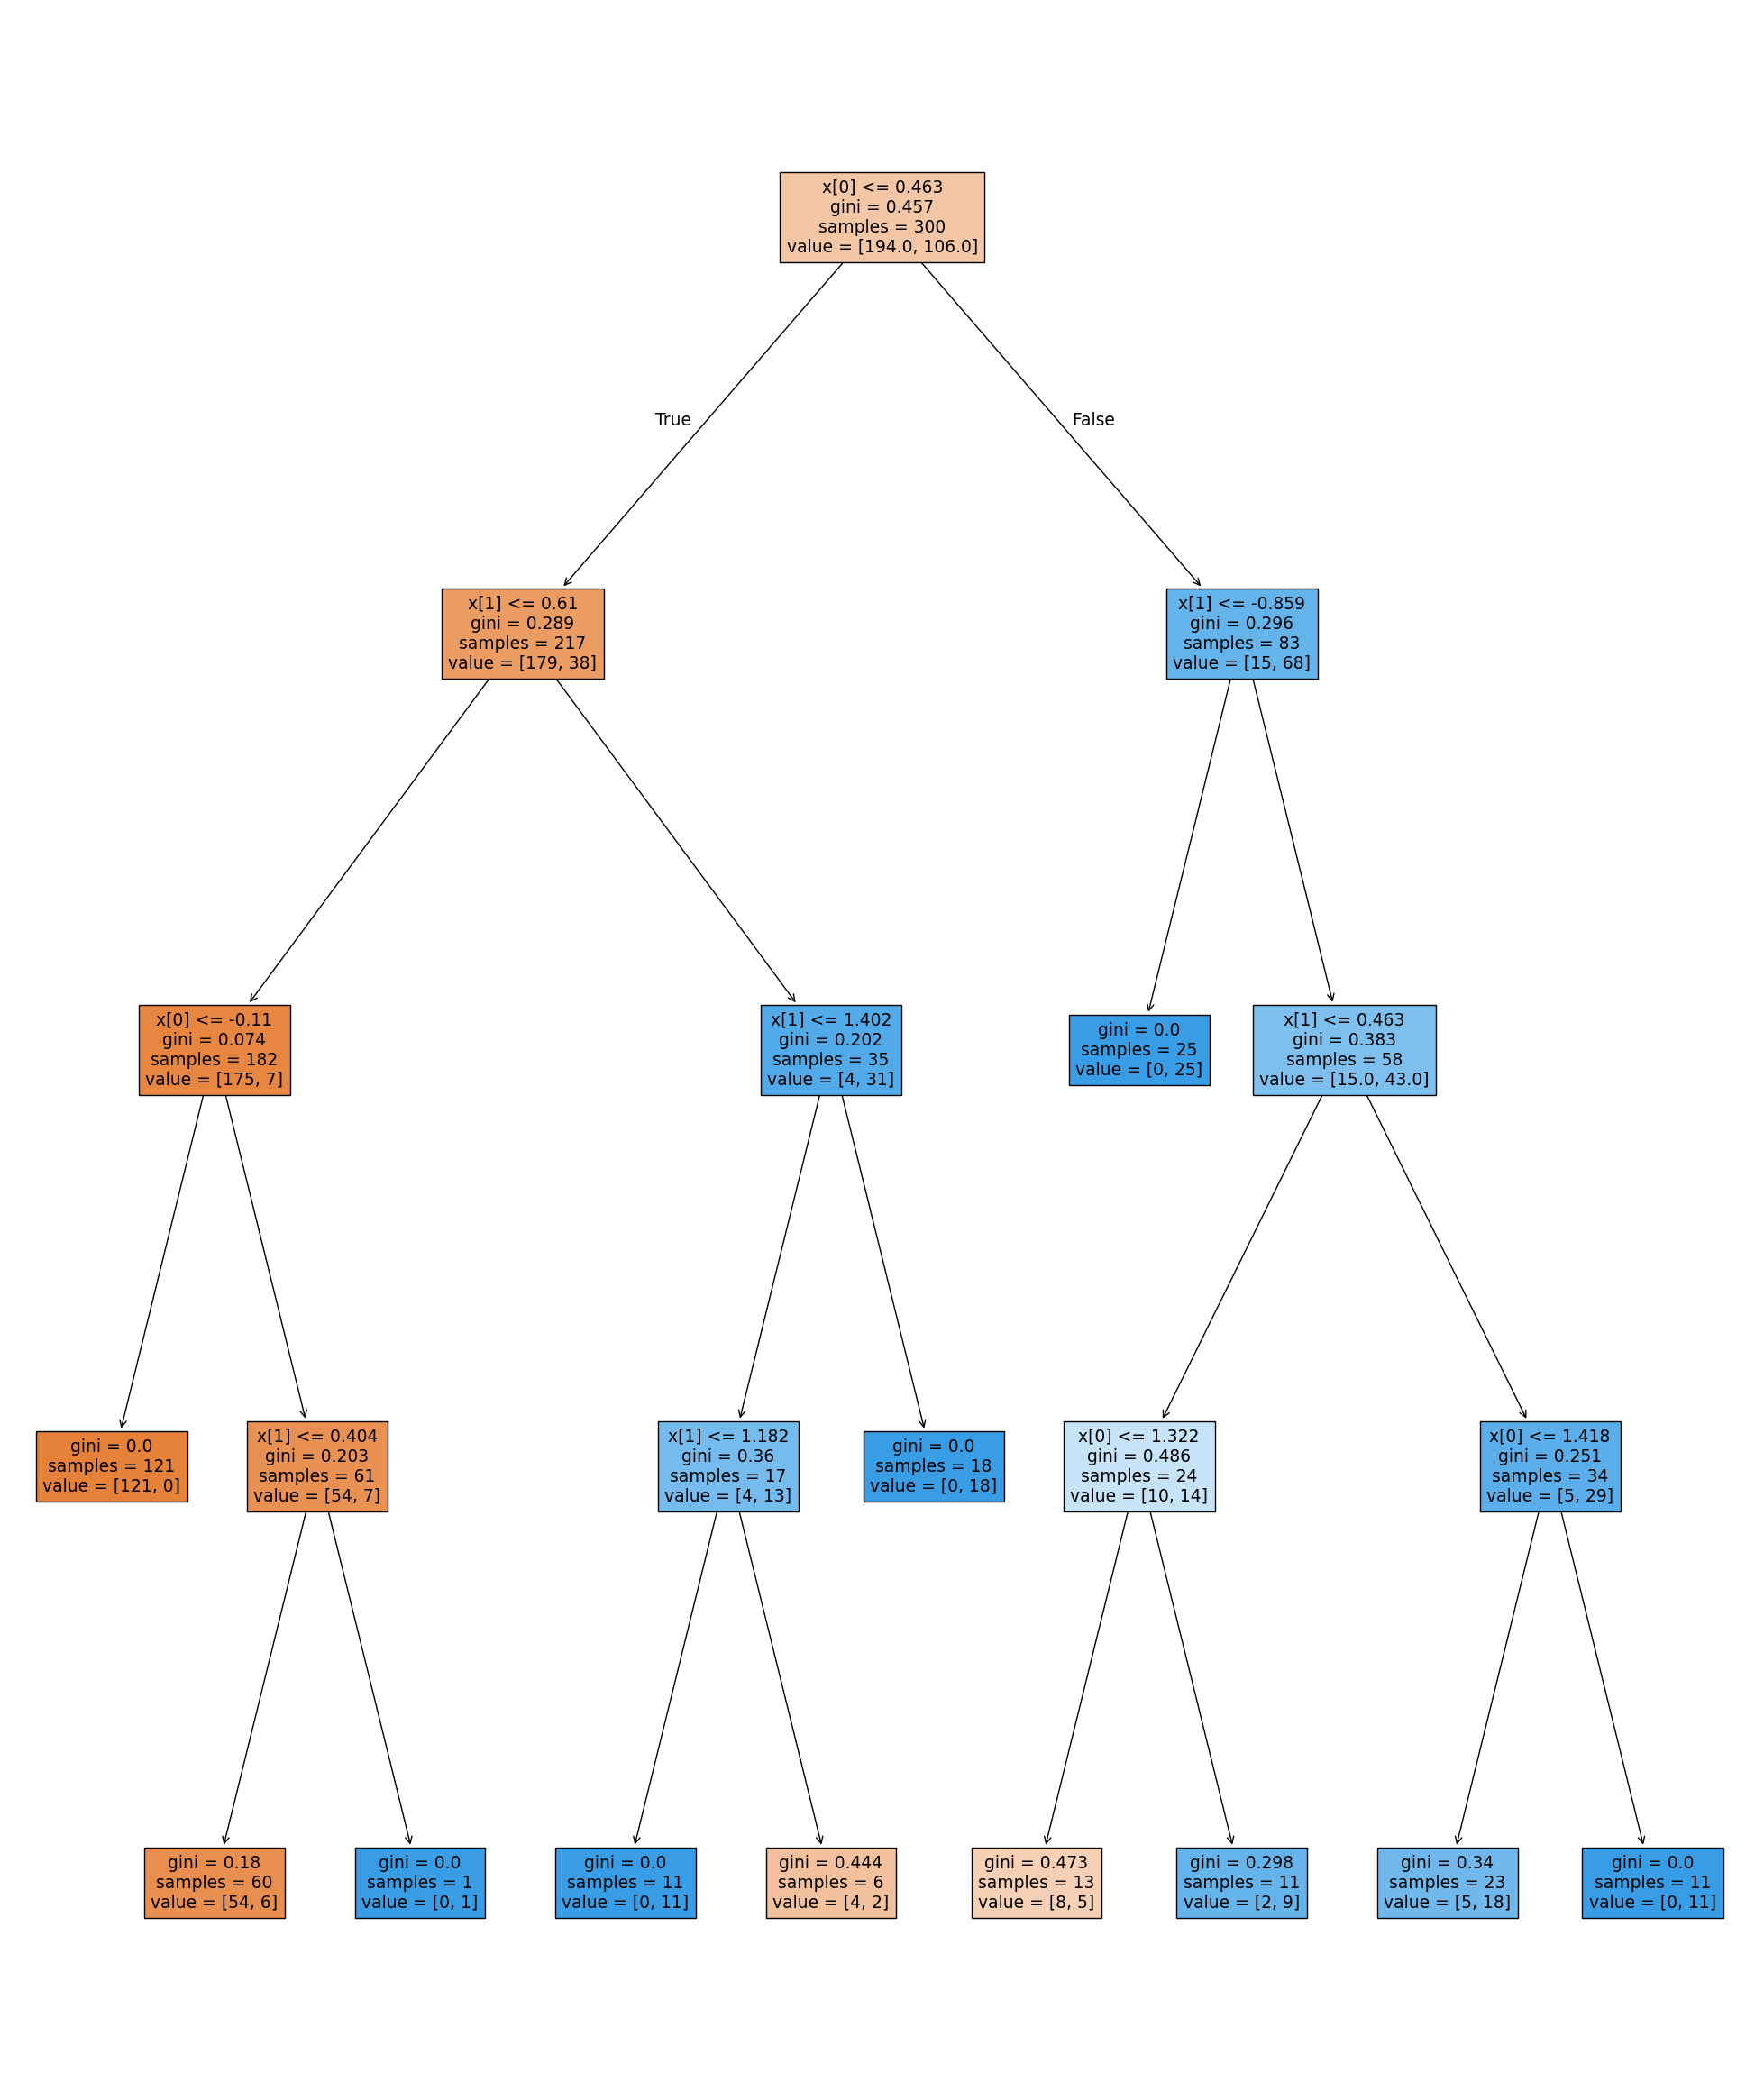

In [23]:
from sklearn import tree
fig = plt.figure(figsize=(25,30))
g=tree.plot_tree(mod,filled=True)

In [24]:
y_pre = mod.predict(x_test)
y_pre

array([1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0])

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pre))

print("\nClassification Report")
print(classification_report(y_test, y_pre))

Confusion Matrix
[[59  4]
 [ 5 32]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        63
           1       0.89      0.86      0.88        37

    accuracy                           0.91       100
   macro avg       0.91      0.90      0.90       100
weighted avg       0.91      0.91      0.91       100

